# tmp — aug25

**Motivation**: scratch notebook <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_TemporalSC'))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

In [3]:
torch.cuda.device_count()

2

In [4]:
torch.utils.data.DataLoader

torch.utils.data.dataloader.DataLoader

In [5]:
a = 'poisson_Kyoto16-wht_t-32_b-4_kms-(512,1,1)_<ngd|lin>'
b = 'b200-ep2000-lr(0.001)_temp(0.05)_gr(200)_(2025_07_25,11:31)'

tr, meta = load_model(pjoin(a, b), device=device)

100%|█████████████████████████████████| 50/50 [01:32<00:00,  1.84s/it]


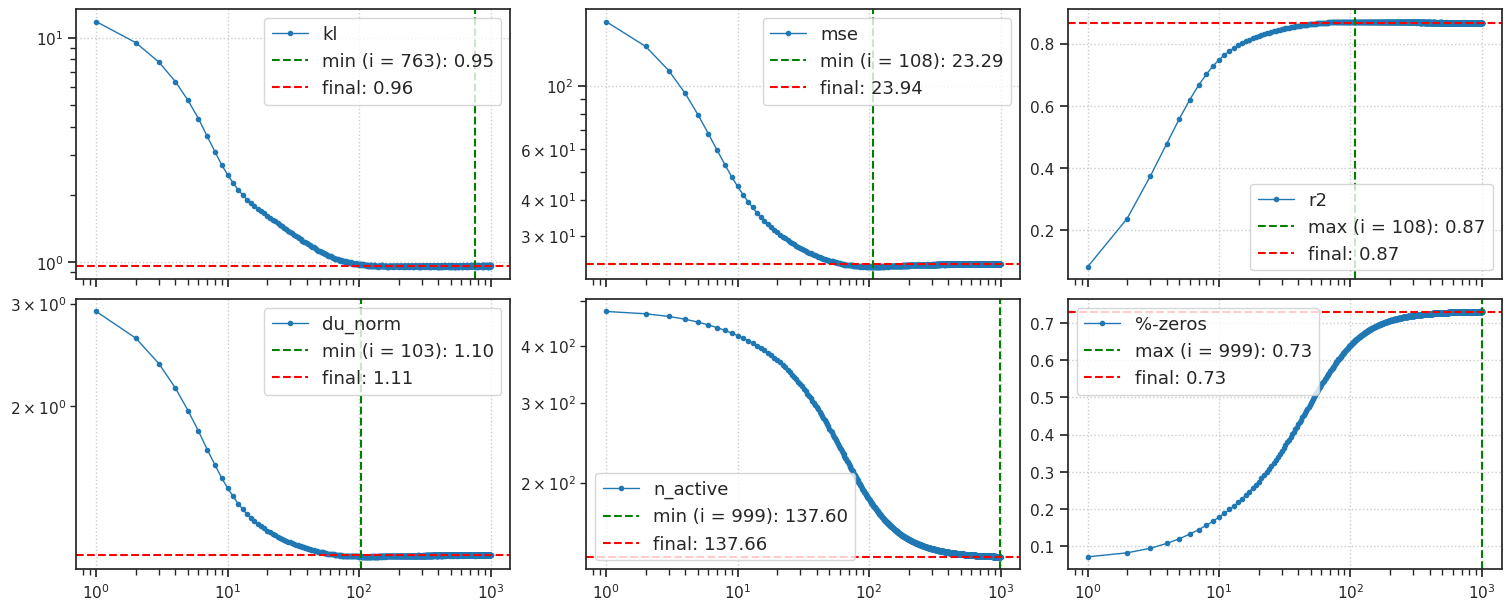

CPU times: user 1min 33s, sys: 145 ms, total: 1min 33s
Wall time: 1min 33s


In [6]:
%%time


kws = dict(
    t_total=1000,
    n_data_batches=-1,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='C0')

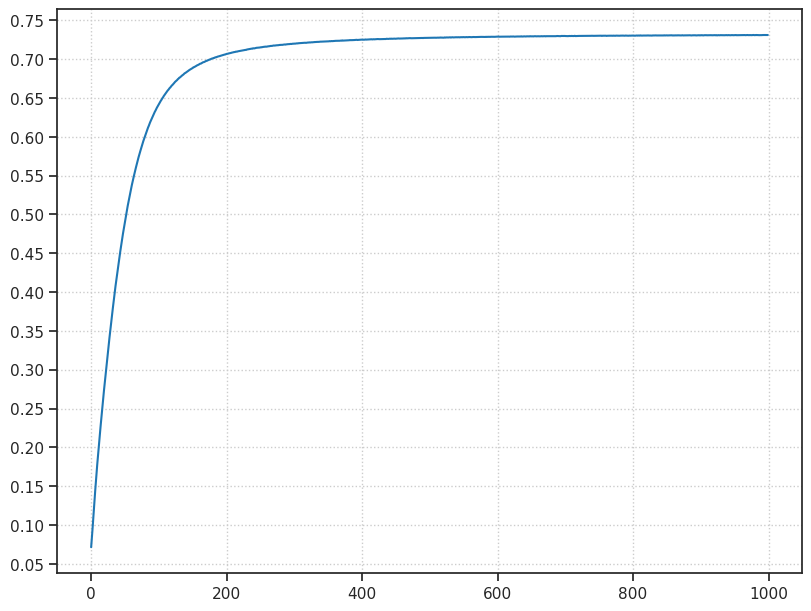

In [7]:
fig, ax = create_figure(1, 1, (8, 6))
ax.plot(results['%-zeros'])
ax.locator_params(axis='y', nbins=25)
ax.grid()